In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(train_images, train_labels), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# reshape to (28,28,1)
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')

# normalize [-1,1]
train_images = (train_images - 127.5) / 127.5

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(train_images)\
                                .shuffle(BUFFER_SIZE)\
                                .batch(BATCH_SIZE)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def build_generator(latent_dim):

    model = tf.keras.Sequential()

    model.add(layers.Dense(7*7*128, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7,7,128)))

    model.add(layers.Conv2DTranspose(128,(5,5),
                                     strides=(1,1),
                                     padding='same',
                                     use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64,(5,5),
                                     strides=(2,2),
                                     padding='same',
                                     use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # final layer -> 28x28
    model.add(layers.Conv2DTranspose(1,(5,5),
                                     strides=(2,2),
                                     padding='same',
                                     use_bias=False,
                                     activation='tanh'))

    return model

In [ ]:
def build_discriminator():

    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64,(5,5),strides=(2,2),
                            padding='same',
                            input_shape=[28,28,1]))

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128,(5,5),strides=(2,2),padding='same'))

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

In [ ]:
latent_dim = 100

generator = build_generator(latent_dim)
discriminator = build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)

    total_loss = real_loss + fake_loss

    return total_loss


def generator_loss(fake_output):

    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
@tf.function
def train_step(images):

    noise = tf.random.normal([BATCH_SIZE, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss,
                                               generator.trainable_variables)

    gradients_of_discriminator = disc_tape.gradient(disc_loss,
                                                    discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator,
                                            generator.trainable_variables))

    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator,
                                                discriminator.trainable_variables))

    return gen_loss, disc_loss

In [ ]:
def generate_images(model, epoch, test_input):

    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4,4,i+1)
        plt.imshow(predictions[i,:,:,0]*127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.show()

Epoch 5, Generator Loss: 0.9857891201972961, Discriminator Loss: 1.0852351188659668


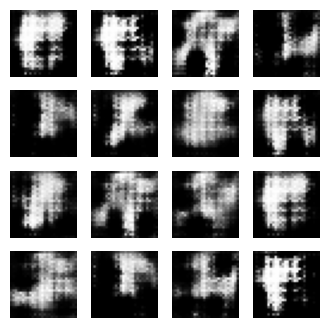

Epoch 10, Generator Loss: 0.9329795837402344, Discriminator Loss: 1.0297377109527588


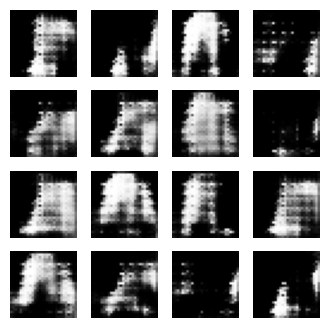

Epoch 15, Generator Loss: 1.3030860424041748, Discriminator Loss: 0.9861158132553101


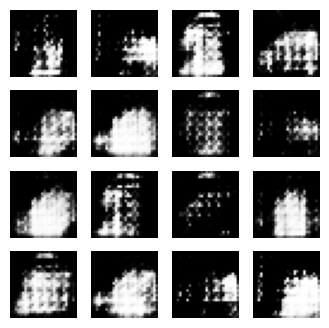

Epoch 20, Generator Loss: 2.0929620265960693, Discriminator Loss: 0.7782012224197388


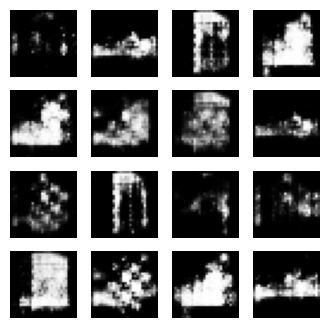

Epoch 25, Generator Loss: 1.667742371559143, Discriminator Loss: 0.7605395913124084


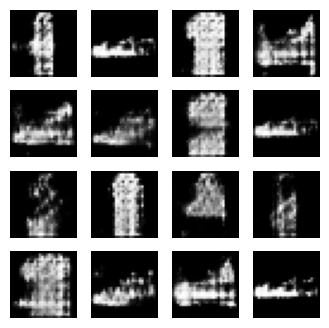

Epoch 30, Generator Loss: 1.3905048370361328, Discriminator Loss: 0.8002018332481384


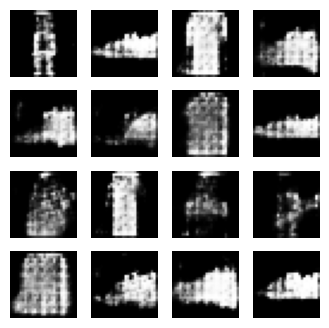

In [ ]:
EPOCHS = 30
noise_seed = tf.random.normal([16, latent_dim])

gen_history = []
disc_history = []

for epoch in range(EPOCHS):

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(image_batch)

    gen_history.append(gen_loss)
    disc_history.append(disc_loss)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}, Generator Loss: {gen_loss}, Discriminator Loss: {disc_loss}")
        generate_images(generator, epoch+1, noise_seed)

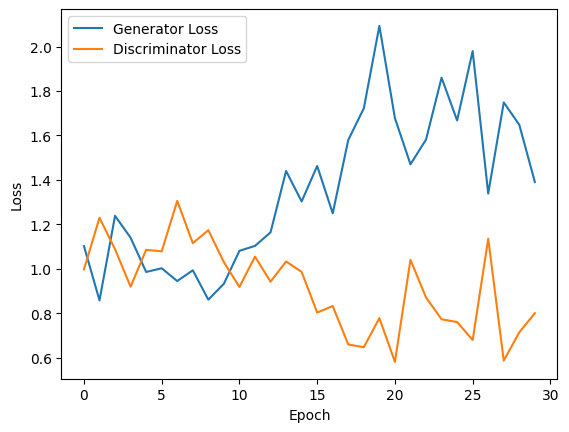

In [ ]:
plt.plot(gen_history, label="Generator Loss")
plt.plot(disc_history, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()